In [7]:
import numba
from numba import cuda
from matplotlib import pyplot
import numpy as np
import time

img = pyplot.imread("image.jpg")
img2 = pyplot.imread("resized_fish.jpg")

#grayImg =

height = len(img)
width = len(img[0])
pixelCount = height*width
print(height,"*",width," = ",pixelCount," pixels")
print(len(img2),"*",len(img2[0]))

#print(img)
#pyplot.imshow(img)
#pyplot.show()

2552 * 3840  =  9799680  pixels
2552 * 3840


In [6]:
@cuda.jit
def binarization(src, dst, threshold):
  # where are we in the input?
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

  if y < src.shape[0] and x < src.shape[1]:
    src[y, x] = [255 if src[y, x] > threshold else 0]

devSrc = cuda.to_device(tmp)
devDst = cuda.device_array_like(img)

blockSide = 16
blockSize = (blockSide, blockSide)

gridSideX = (width+blockSide-1)//blockSide
gridSideY = (height+blockSide-1)//blockSide
gridSize = (gridSideX,gridSideY)

binarization[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

new_img = devDst.copy_to_host()

pyplot.imshow(new_img)
pyplot.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

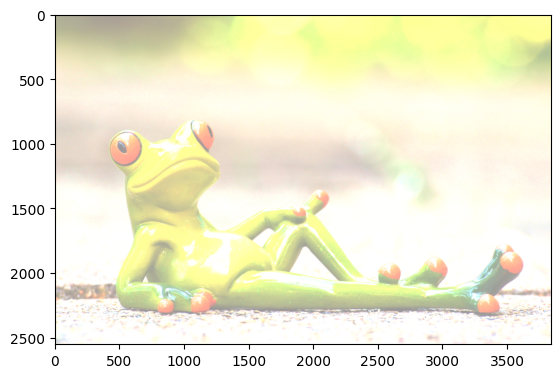

In [8]:
@cuda.jit
def brightness_control(src, dst, value):
  # where are we in the input?
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if y < src.shape[0] and x < src.shape[1]:
    for i in range(3):
      dst[y, x, i]=min(255,(max(0,src[y, x, i]+value)))

devSrc = cuda.to_device(img)
devDst = cuda.device_array_like(img)

blockSide = 16
blockSize = (blockSide, blockSide)

gridSideX = (width+blockSide-1)//blockSide
gridSideY = (height+blockSide-1)//blockSide
gridSize = (gridSideX,gridSideY)

brightness_control[gridSize, blockSize](devSrc, devDst, 150)
cuda.synchronize()

new_img = devDst.copy_to_host()

pyplot.imshow(new_img)
pyplot.show()

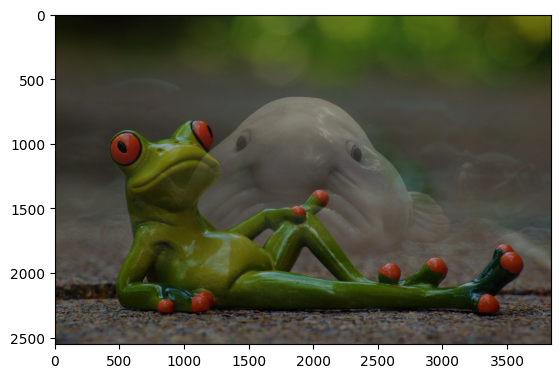

In [10]:
@cuda.jit
def blend_images(src1, src2, q, dst):
  # where are we in the input?
  x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
  if y < src1.shape[0] and x < src1.shape[1]:
    for i in range(3):
      dst[y][x][i]=q*src1[y][x][i]+(1-q)*src2[y][x][i]

devSrc = cuda.to_device(img)
devSrc2 = cuda.to_device(img2)

devDst = cuda.device_array_like(img)

blockSide = 16
blockSize = (blockSide, blockSide)

gridSideX = (width+blockSide-1)//blockSide
gridSideY = (height+blockSide-1)//blockSide
gridSize = (gridSideX,gridSideY)

blend_images[gridSize, blockSize](devSrc, devSrc2, 0.6, devDst)
cuda.synchronize()

new_img = devDst.copy_to_host()

pyplot.imshow(new_img)
pyplot.show()